# BOCPD Results Visualization

Generates publication-quality figures for the ablation study and PMF validation:
1. Ablation RMSE/MAE heatmap (strategy × threshold)
2. PMF overlay: all 4 window strategies vs simulation ground truth — **shared x-axis per grid**
3. KL divergence heatmap (strategy × evaluation time t)
4. Prediction trace: 4-panel per strategy × dataset (Z0=5 and Z0=80)

In [1]:
# ── Parameters ─────────────────────────────────────────────────────────────────
ARRIVAL_DIR = 'data_integrated/arrival_data'
NPZ_DIR     = 'Simulation_code'
RESULT_DIR  = 'data_integrated/result_data'

CSV_Z5  = 'initial_value_5_samples_500.csv'
CSV_Z80 = 'initial_value_80_samples_500.csv'

STRATEGIES = [
    dict(id='fixed_ws5',     label='Fixed ws=5',
         kwargs=dict(adaptive=False, window_size=5)),
    dict(id='fixed_ws10',    label='Fixed ws=10',
         kwargs=dict(adaptive=False, window_size=10)),
    dict(id='adaptive_std',  label='Adaptive (rolling_std)',
         kwargs=dict(adaptive=True, window_method='rolling_std',
                     adaptive_w_min=3, adaptive_w_max=15,
                     adaptive_threshold=True, threshold_k=2.0)),
    dict(id='adaptive_ewma', label='Adaptive (EWMA)',
         kwargs=dict(adaptive=True, window_method='ewma',
                     adaptive_w_min=3, adaptive_w_max=15,
                     adaptive_threshold=True, threshold_k=2.0)),
]

ALARM_THRESHOLD = 0.015
HAZARD_LAMBDA   = 50.0
# N is intentionally left small here — src/pmf.py auto_N=True raises it as needed
PMF_N   = 50
T_VALS  = [1, 2, 3, 4, 5, 6, 7]

In [2]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from src import UnifiedPredictor, PredictionConfig
from src.pmf import transient_distribution_piecewise
from src.utils import calculate_kl_divergence

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

STRAT_COLORS = {
    'fixed_ws5':     '#e41a1c',
    'fixed_ws10':    '#377eb8',
    'adaptive_std':  '#4daf4a',
    'adaptive_ewma': '#ff7f00',
}
print('Imports OK')

Imports OK


## 1 · Ablation RMSE / MAE Heatmap

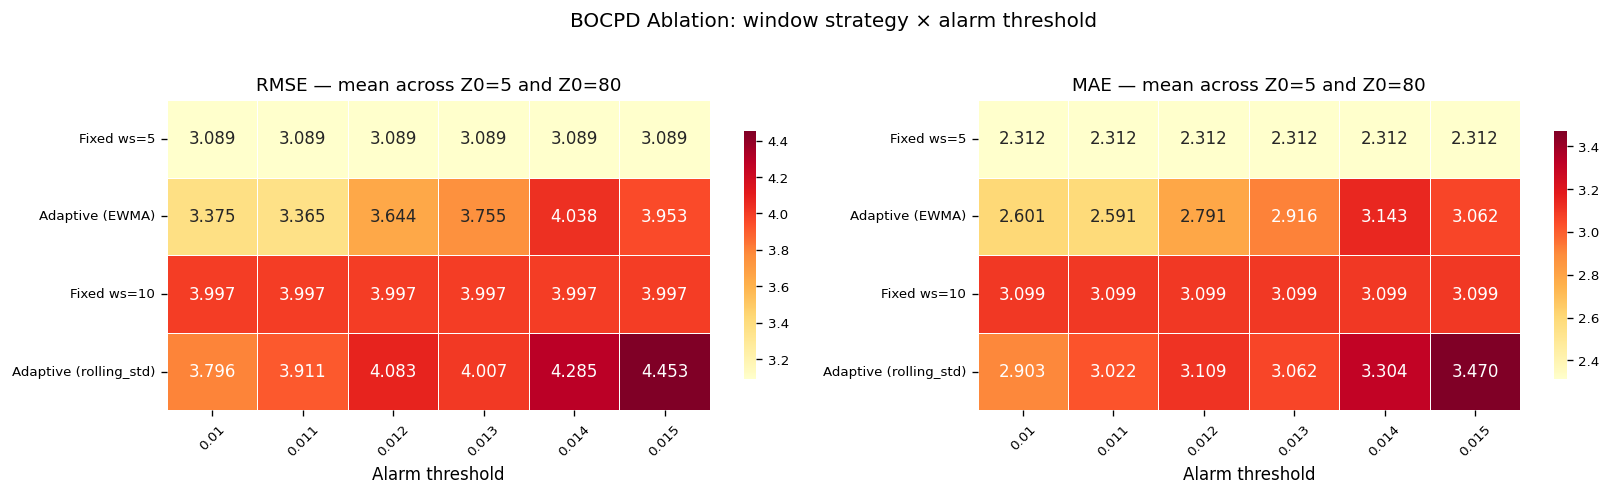

In [3]:
abl = pd.read_csv(os.path.join(RESULT_DIR, 'bocpd_ablation_results.csv'))

agg = (abl.groupby(['strategy', 'alarm_threshold'])
          [['rmse', 'mae', 'direction_accuracy']]
          .mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['rmse', 'mae']):
    pivot = agg.pivot(index='strategy', columns='alarm_threshold', values=metric)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{metric.upper()} — mean across Z0=5 and Z0=80')
    ax.set_xlabel('Alarm threshold')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('BOCPD Ablation: window strategy × alarm threshold', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'ablation_heatmap.png'), bbox_inches='tight')
plt.show()

## 2 · Run BOCPD for All Strategies — Z0=5 and Z0=80

In [4]:
def _run_and_extract(strat, data):
    """Run BOCPD for one strategy on one dataset; return (Z_piece, dt, predictor)."""
    cfg = PredictionConfig(
        method='cpd_bayesian',
        hazard_lambda=HAZARD_LAMBDA,
        alarm_threshold=ALARM_THRESHOLD,
        plot=False, verbose=False,
        **strat['kwargs'],
    )
    up = UnifiedPredictor(cfg)
    up.predict(data)
    pred = up.predictor
    r = pred.results
    step_raw  = r.get('predicted_step_function', r.get('stepwise_value', []))
    step_vals = pd.Series(step_raw).dropna().values
    times_raw = r.get('prediction_times', data['time'].values)
    times = times_raw.values if hasattr(times_raw, 'values') else np.asarray(times_raw)
    n = len(step_vals)
    t_slice = times[:n] if len(times) >= n else times
    dt = np.diff(t_slice, prepend=t_slice[0])
    dt = np.where(dt <= 0, 0.02, dt)
    Z_piece = np.maximum(step_vals, 1e-6)
    return Z_piece, dt, pred


data_z5  = pd.read_csv(os.path.join(ARRIVAL_DIR, CSV_Z5))
data_z80 = pd.read_csv(os.path.join(ARRIVAL_DIR, CSV_Z80))

predictors_z5  = {}
predictors_z80 = {}

for strat in STRATEGIES:
    print(f"Z0=5  | {strat['label']} ...")
    predictors_z5[strat['id']]  = _run_and_extract(strat, data_z5)
    print(f"Z0=80 | {strat['label']} ...")
    predictors_z80[strat['id']] = _run_and_extract(strat, data_z80)

# convenience alias for PMF sections (use Z0=5)
predictors = predictors_z5
print('Done.')

Z0=5  | Fixed ws=5 ...
Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0293
  101/501, CP prob=0.0291
  151/501, CP prob=0.0284
  201/501, CP prob=0.0350
  251/501, CP prob=0.0333
  301/501, CP prob=0.0231
  351/501, CP prob=0.0213
  401/501, CP prob=0.0220
  451/501, CP prob=0.0231
  501/501, CP prob=0.0234
Running windowed prediction...
Z0=80 | Fixed ws=5 ...
Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0225
  101/501, CP prob=0.0406
  151/501, CP prob=0.0211
  201/501, CP prob=0.0225
  251/501, CP prob=0.0215
  301/501, CP prob=0.0285
  351/501, CP prob=0.0255
  401/501, CP prob=0.0244
  451/501, CP prob=0.0241
  501/501, CP prob=0.0274
Running windowed prediction...
Z0=5  | Fixed ws=10 ...
Running online BOCPD...
  1/501, CP prob=0.0000
  51/501, CP prob=0.0293
  101/501, CP prob=0.0291
  151/501, CP prob=0.0284
  201/501, CP prob=0.0350
  251/501, CP prob=0.0333
  301/501, CP prob=0.0231
  351/501, CP prob=0.0213
  401/501, CP prob=0.0220

## 3 · PMF Overlay: All Strategies vs Simulation — shared x-axis

Saved → data_integrated/result_data/pmf_overlay_serv10_all_strategies.png  (global_xmax=385)


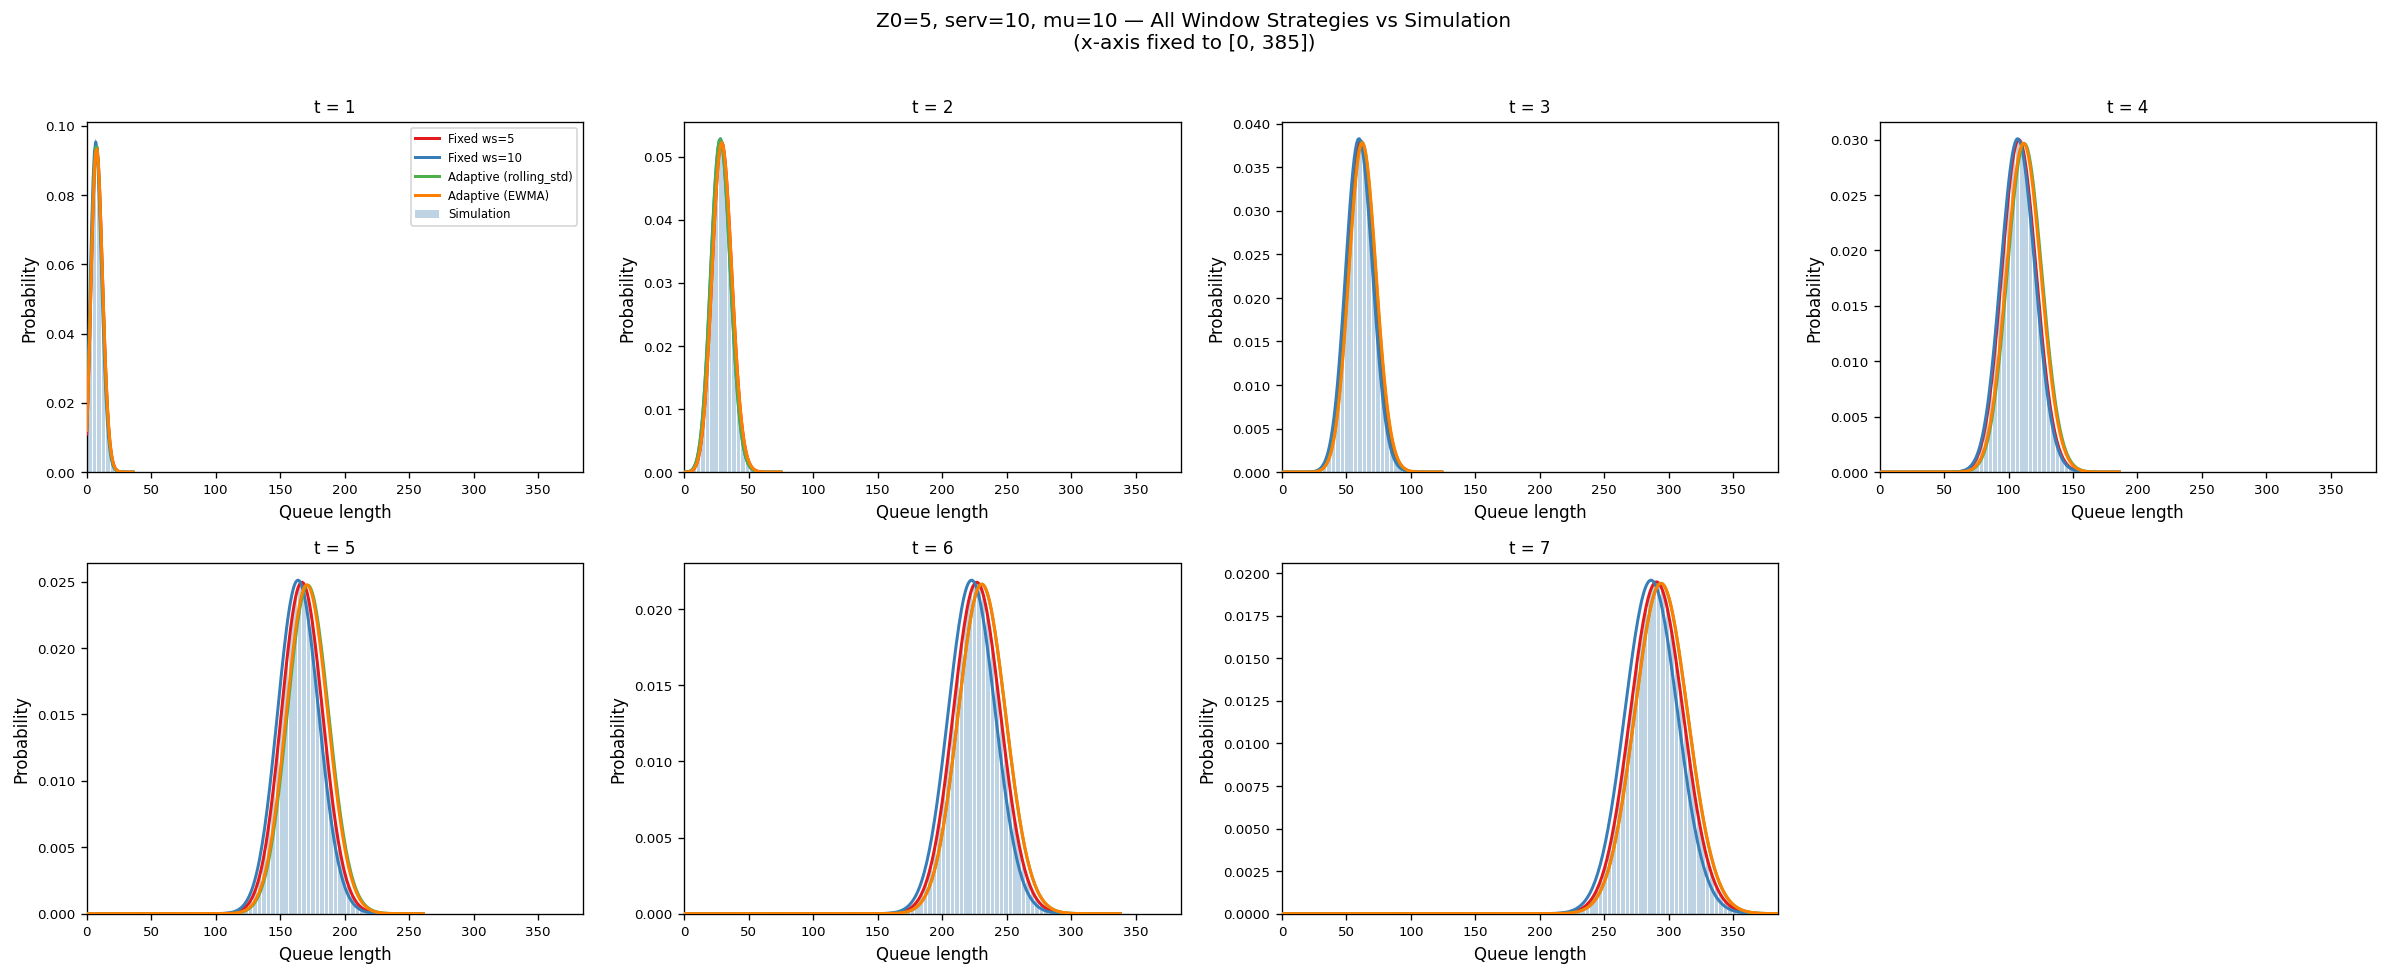

In [5]:
def load_npz(serv, T, t):
    fname = f'pmf_CoxM1_Z05_serv{serv}_T{T}_t{t}_v2.npz'
    path  = os.path.join(NPZ_DIR, fname)
    if not os.path.exists(path):
        return None, None
    d = np.load(path)
    return d['pmf'], float(d['service_rate'])


def plot_pmf_overlay_grid(serv, T, t_vals, title_prefix=''):
    """PMF overlay grid with shared x-axis across all panels."""
    n_cols = min(4, len(t_vals))
    n_rows = (len(t_vals) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes_flat = np.array(axes).flatten()

    # --- Pass 1: compute all PMFs and track global x range ---
    panel_data = []   # list of (t, sim_pmf, mu, {strat_id: pmf_pred})
    x_max_list = []

    for t in t_vals:
        sim_pmf, mu = load_npz(serv, T, t)
        if sim_pmf is None:
            panel_data.append(None)
            continue
        preds_for_t = {}
        for strat in STRATEGIES:
            sid = strat['id']
            Z_piece, dt, _ = predictors[sid]
            T_total  = dt.sum()
            t_target = min(float(t), T_total * 0.99)
            try:
                pmf_pred = transient_distribution_piecewise(
                    Z_piece, dt, mu=mu, m=1, t=t_target, N=PMF_N)
                preds_for_t[sid] = pmf_pred
                # find rightmost index with non-negligible mass
                nz = np.where(pmf_pred > 1e-5)[0]
                if len(nz):
                    x_max_list.append(nz[-1])
            except Exception:
                preds_for_t[sid] = None
        # also check sim support
        nz_sim = np.where(sim_pmf > 1e-5)[0]
        if len(nz_sim):
            x_max_list.append(nz_sim[-1])
        panel_data.append((t, sim_pmf, mu, preds_for_t))

    global_xmax = (max(x_max_list) + 10) if x_max_list else 200

    # --- Pass 2: draw with shared xlim ---
    for ax_i, entry in enumerate(panel_data):
        ax = axes_flat[ax_i]
        if entry is None:
            ax.set_visible(False)
            continue
        t, sim_pmf, mu, preds_for_t = entry

        ax.bar(np.arange(len(sim_pmf)), sim_pmf,
               color='steelblue', alpha=0.35, label='Simulation', zorder=1)

        for strat in STRATEGIES:
            sid = strat['id']
            pmf_pred = preds_for_t.get(sid)
            if pmf_pred is None:
                continue
            n = min(len(sim_pmf), len(pmf_pred))
            ax.plot(np.arange(n), pmf_pred[:n],
                    color=STRAT_COLORS[sid], lw=1.8,
                    label=strat['label'], zorder=3)

        ax.set_xlim(0, global_xmax)
        ax.set_title(f't = {t}', fontsize=10)
        ax.set_xlabel('Queue length')
        ax.set_ylabel('Probability')
        if ax_i == 0:
            ax.legend(loc='upper right', fontsize=7)

    for ax in axes_flat[len(t_vals):]:
        ax.set_visible(False)

    fig.suptitle(
        f'{title_prefix}Z0=5, serv={serv}, mu={mu:.0f} — All Window Strategies vs Simulation'
        f'\n(x-axis fixed to [0, {global_xmax}])',
        fontsize=12, y=1.01)
    plt.tight_layout()
    fname = os.path.join(RESULT_DIR, f'pmf_overlay_serv{serv}_all_strategies.png')
    plt.savefig(fname, bbox_inches='tight')
    print(f'Saved → {fname}  (global_xmax={global_xmax})')
    plt.show()


plot_pmf_overlay_grid(serv=10, T=10, t_vals=T_VALS)

Saved → data_integrated/result_data/pmf_overlay_serv30_all_strategies.png  (global_xmax=270)


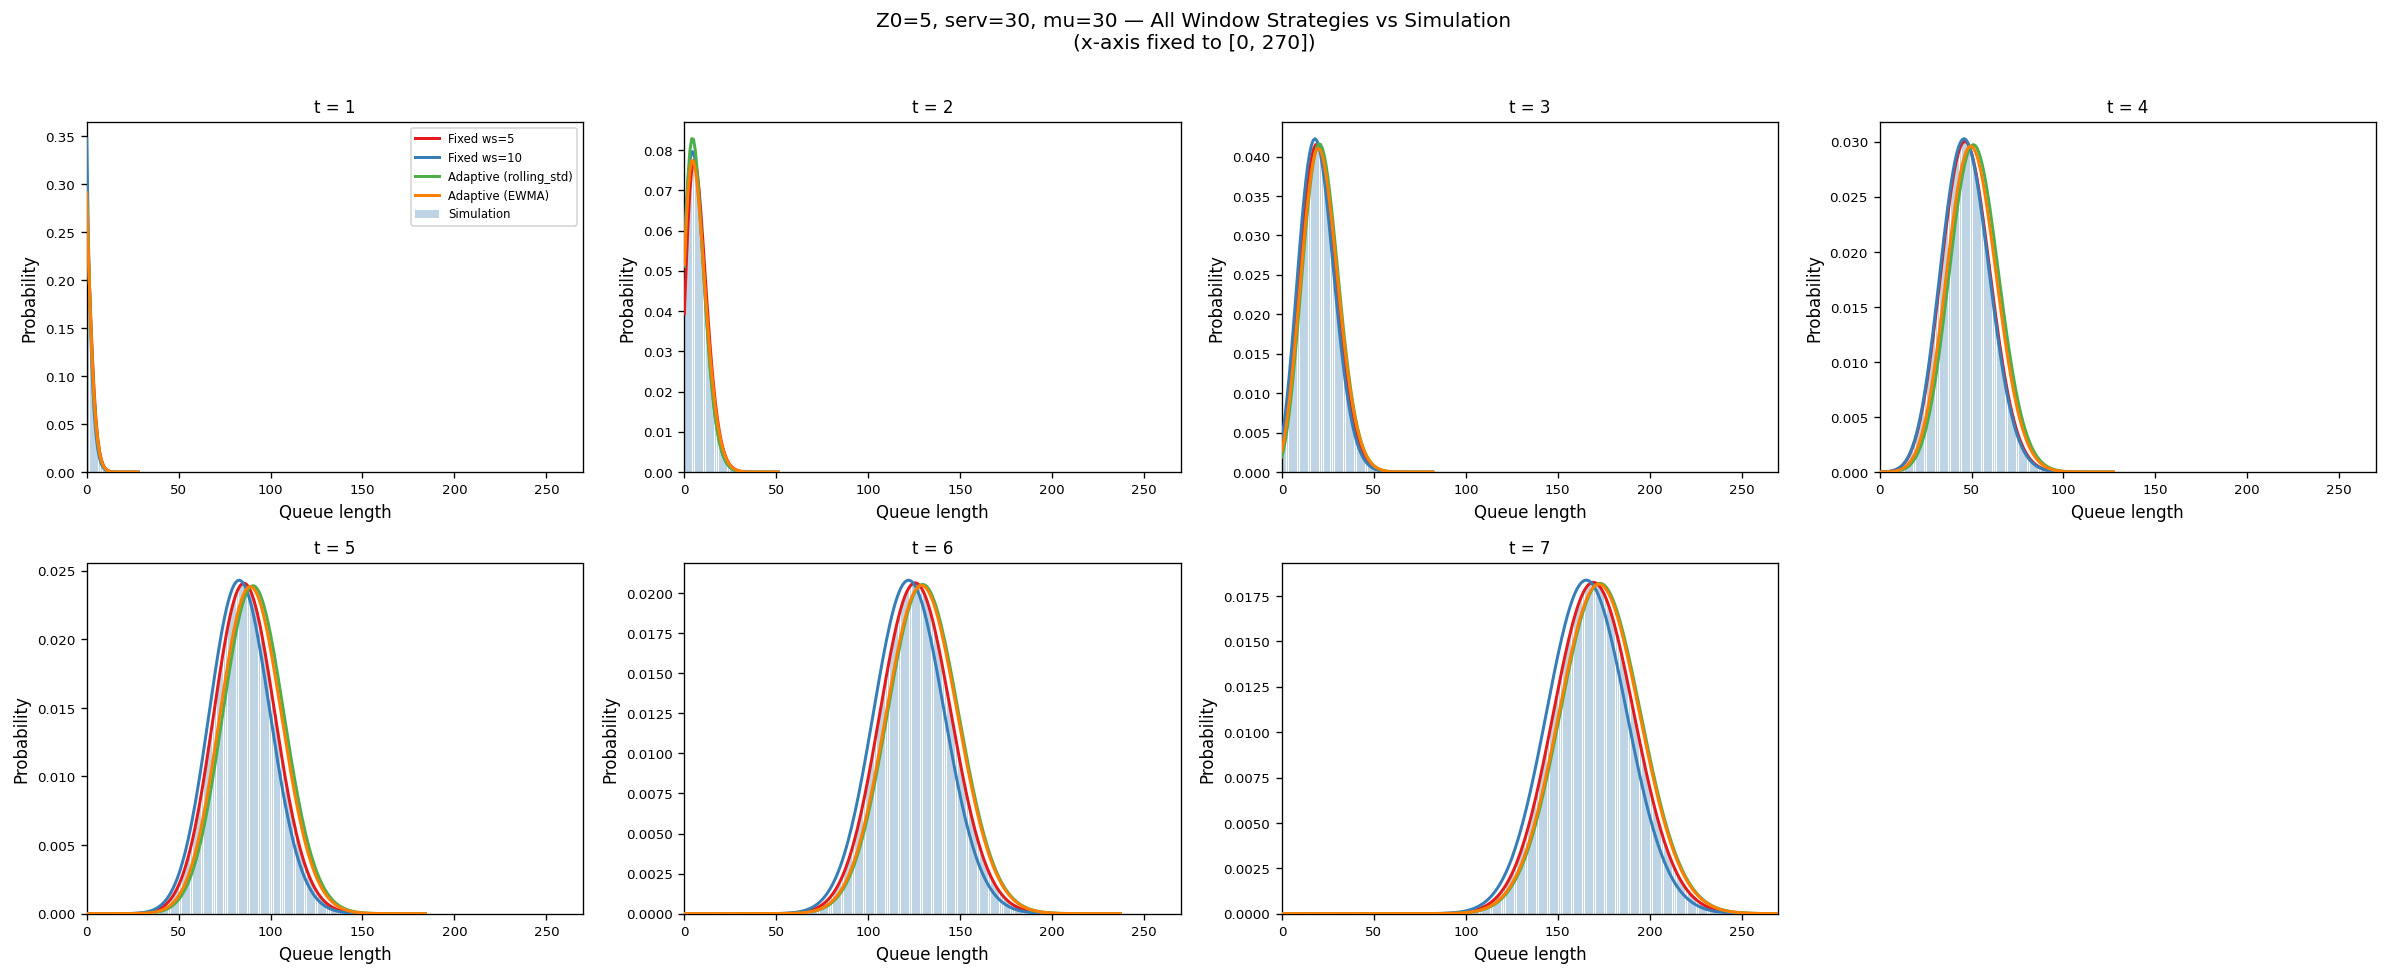

In [6]:
plot_pmf_overlay_grid(serv=30, T=10, t_vals=T_VALS)

## 4 · KL Divergence Heatmap: Strategy × Time t

In [7]:
npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, 'pmf_CoxM1_Z05_serv*_T*_t*_v2.npz')))

kl_rows = []
for npz_path in npz_files:
    fname = os.path.basename(npz_path)
    m = re.match(r'pmf_CoxM1_Z0\d+_serv(\d+)_T(\d+)_t(\d+)_v2\.npz', fname)
    if not m:
        continue
    serv, T_npz, t_npz = int(m.group(1)), int(m.group(2)), int(m.group(3))
    d = np.load(npz_path)
    mu_npz  = float(d['service_rate'])
    sim_pmf = d['pmf']

    for strat in STRATEGIES:
        sid = strat['id']
        Z_piece, dt, _ = predictors[sid]
        T_total  = dt.sum()
        t_target = min(float(t_npz), T_total * 0.99)
        try:
            pmf_pred = transient_distribution_piecewise(
                Z_piece, dt, mu=mu_npz, m=1, t=t_target, N=PMF_N)
            n   = min(len(sim_pmf), len(pmf_pred))
            kl  = calculate_kl_divergence(sim_pmf[:n], pmf_pred[:n])
        except Exception:
            kl = np.nan
        kl_rows.append(dict(strategy_id=sid, strategy=strat['label'],
                             service_rate=serv, T=T_npz, t=t_npz, kl=kl))

df_kl = pd.DataFrame(kl_rows)
print(df_kl.groupby(['strategy', 't'])['kl'].mean().unstack('t').round(4).to_string())

t                           1       2       3       4       5       6       7       8       9       10
strategy                                                                                              
Adaptive (EWMA)         0.0038  0.0028  0.0115  0.0275  0.0303  0.0226  0.0121  0.0386  0.0235  0.0002
Adaptive (rolling_std)  0.0017  0.0048  0.0132  0.0484  0.0464  0.0257  0.0137  0.0660  0.0331  0.0034
Fixed ws=10             0.0040  0.0054  0.0026  0.0024  0.0133  0.0174  0.0188  0.0101  0.0089  0.0632
Fixed ws=5              0.0053  0.0017  0.0014  0.0004  0.0002  0.0002  0.0001  0.0010  0.0007  0.0155


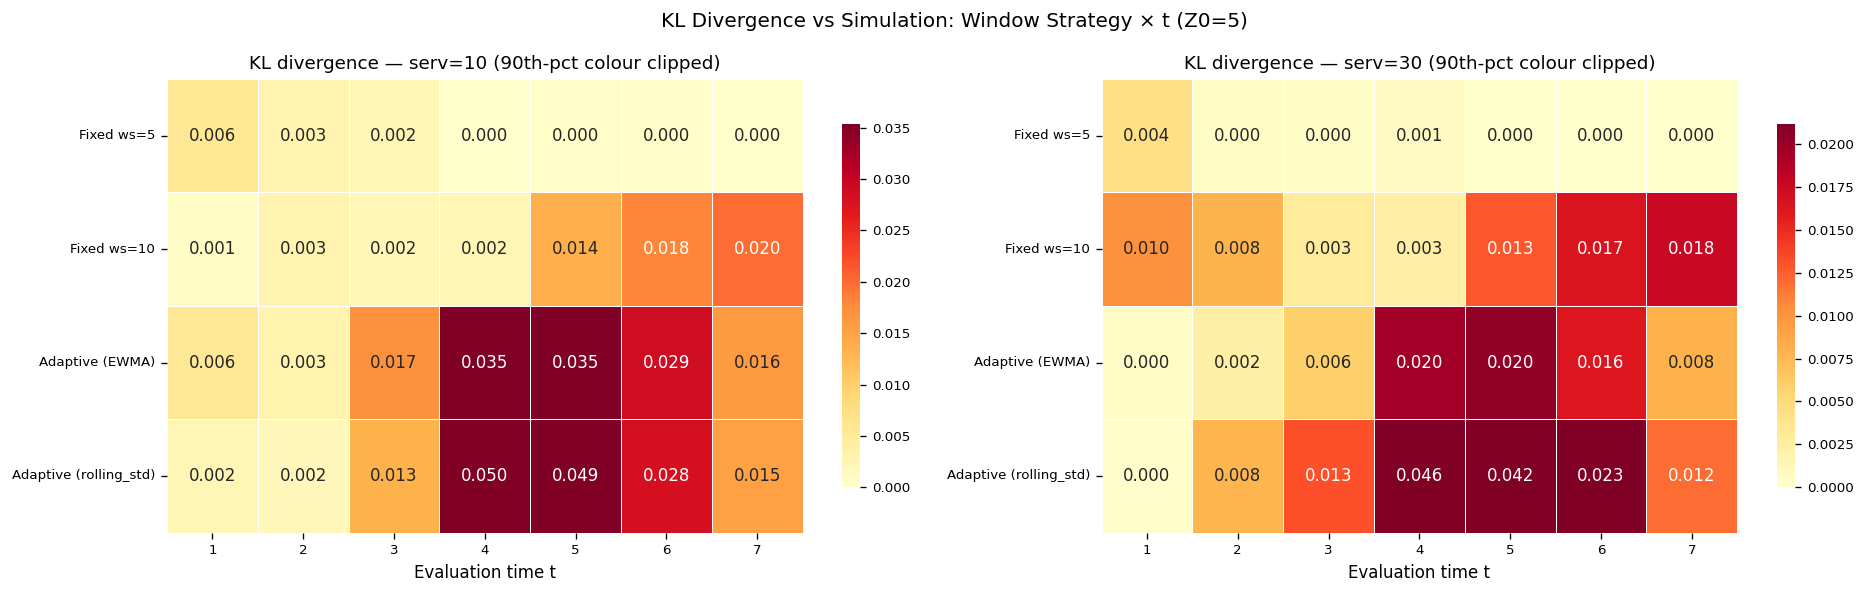

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, serv_val in zip(axes, [10, 30]):
    sub   = df_kl[(df_kl['service_rate'] == serv_val) & df_kl['t'].isin(T_VALS)]
    pivot = (sub.groupby(['strategy', 't'])['kl']
               .mean().reset_index()
               .pivot(index='strategy', columns='t', values='kl'))
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]
    vmax  = np.nanpercentile(pivot.values, 90)
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=vmax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'KL divergence — serv={serv_val} (90th-pct colour clipped)')
    ax.set_xlabel('Evaluation time t')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('KL Divergence vs Simulation: Window Strategy × t (Z0=5)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'kl_heatmap_strategy_vs_t.png'), bbox_inches='tight')
plt.show()

## 5 · Prediction Trace — All Strategies × Both Datasets

Saved → data_integrated/result_data/prediction_trace_fixed_ws5_Z05.png


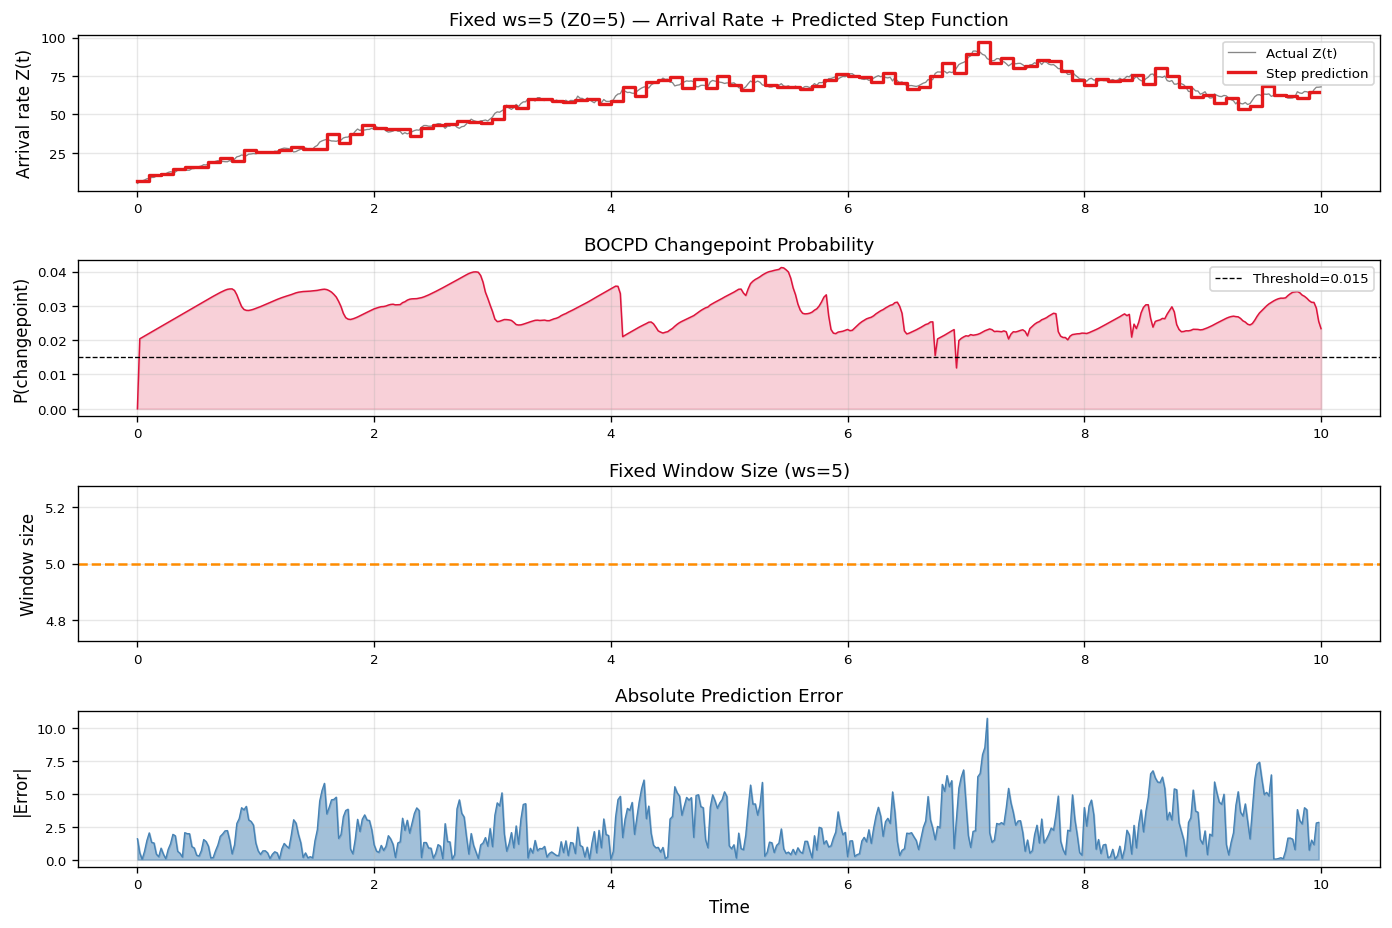

Saved → data_integrated/result_data/prediction_trace_fixed_ws10_Z05.png


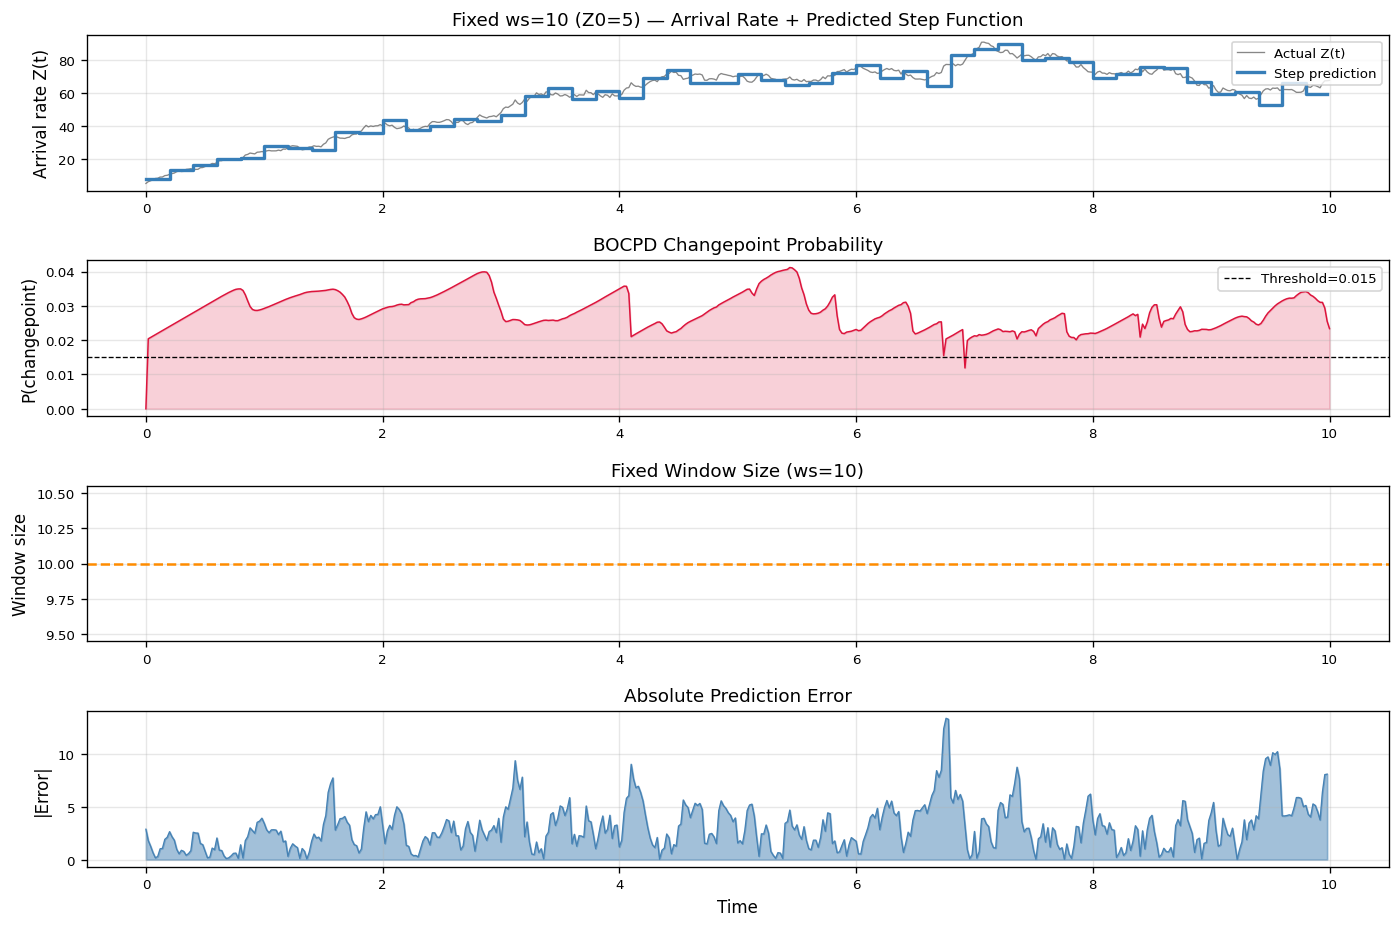

Saved → data_integrated/result_data/prediction_trace_adaptive_std_Z05.png


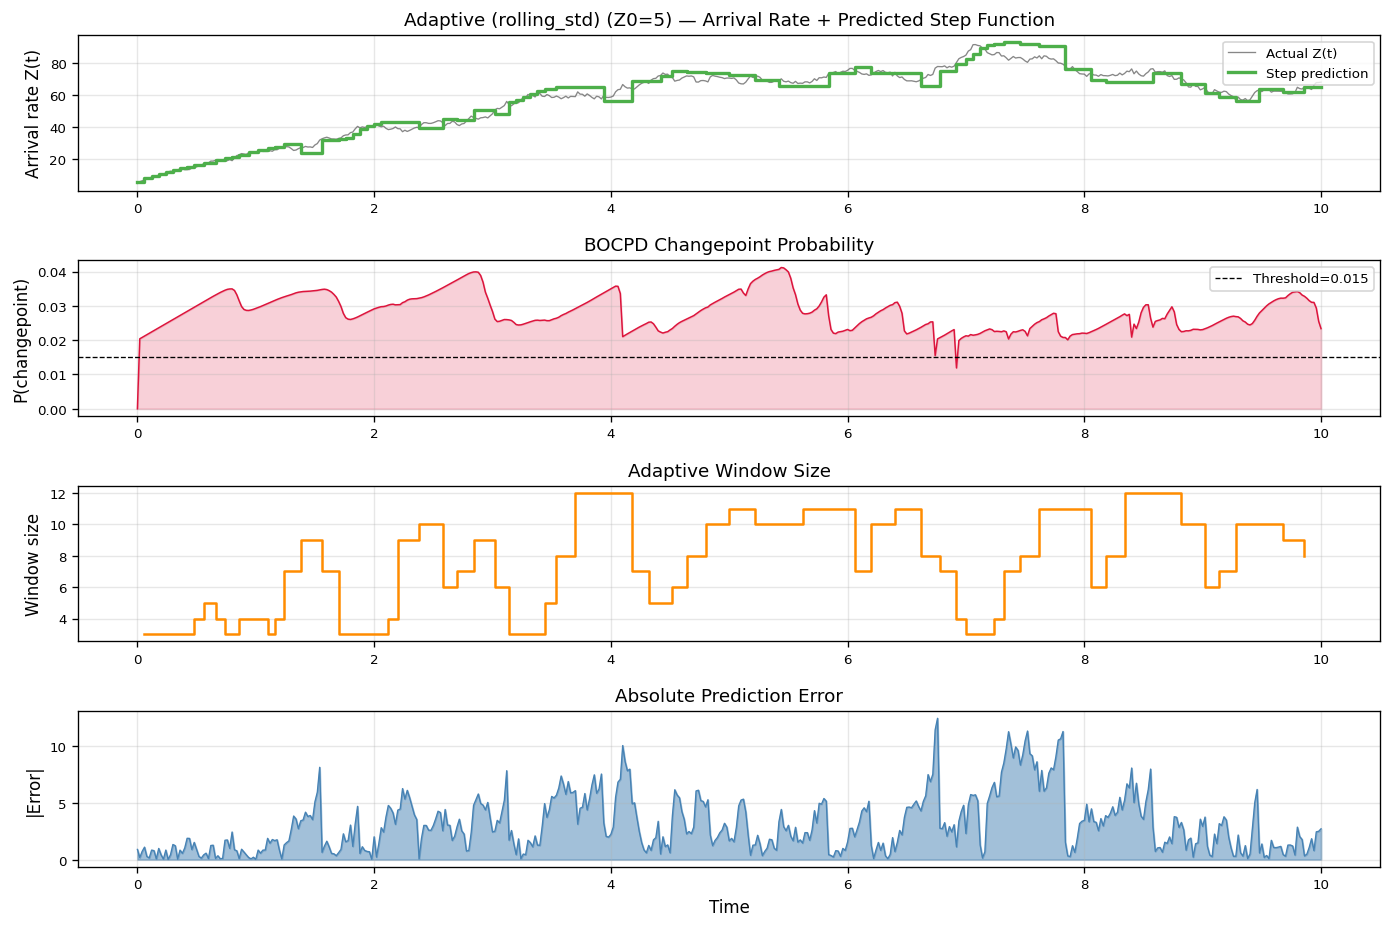

Saved → data_integrated/result_data/prediction_trace_adaptive_ewma_Z05.png


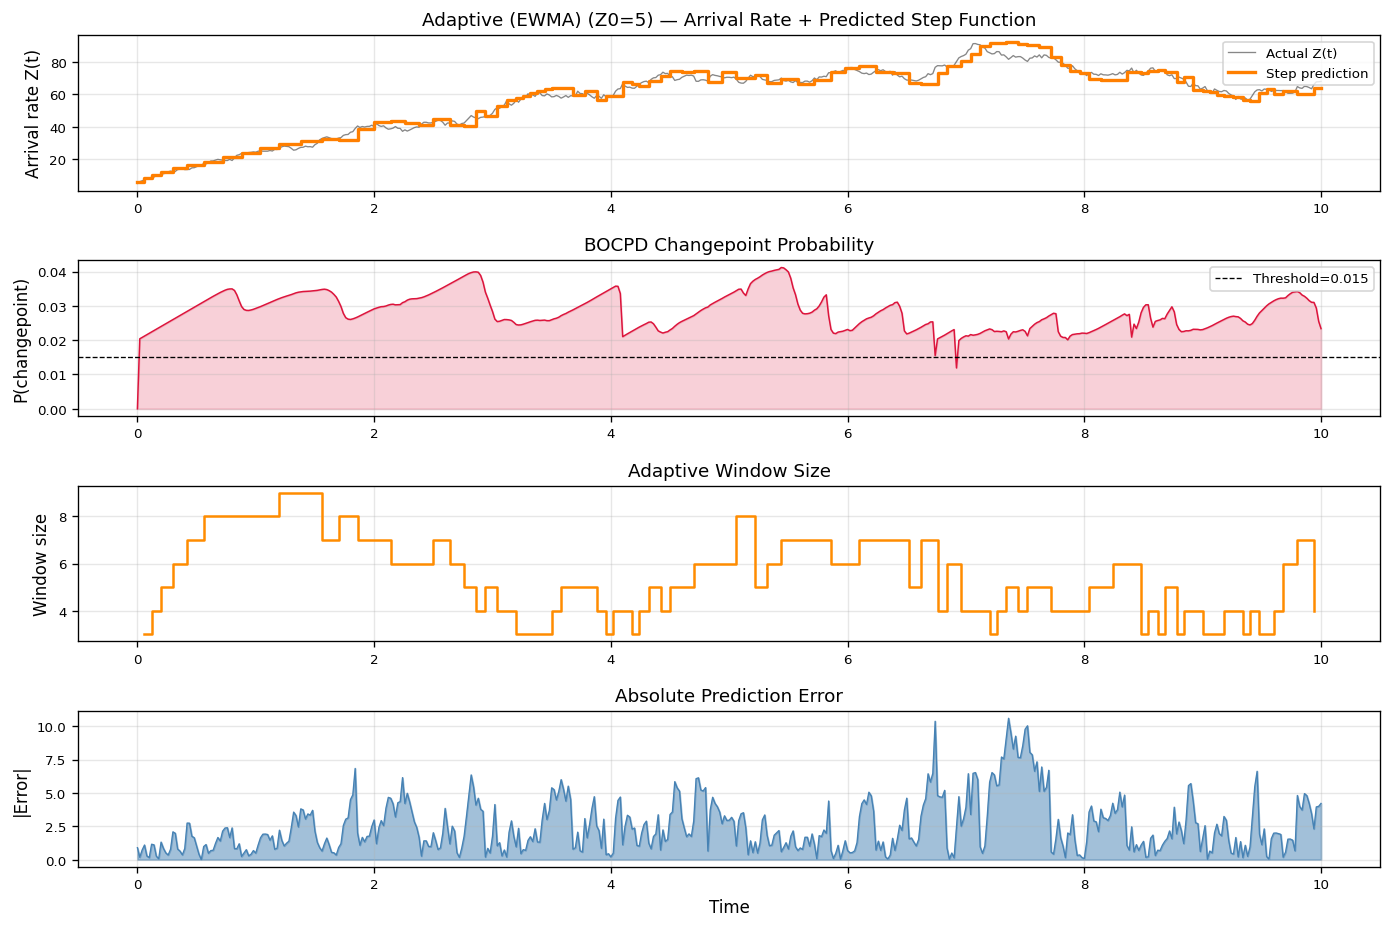

Saved → data_integrated/result_data/prediction_trace_fixed_ws5_Z080.png


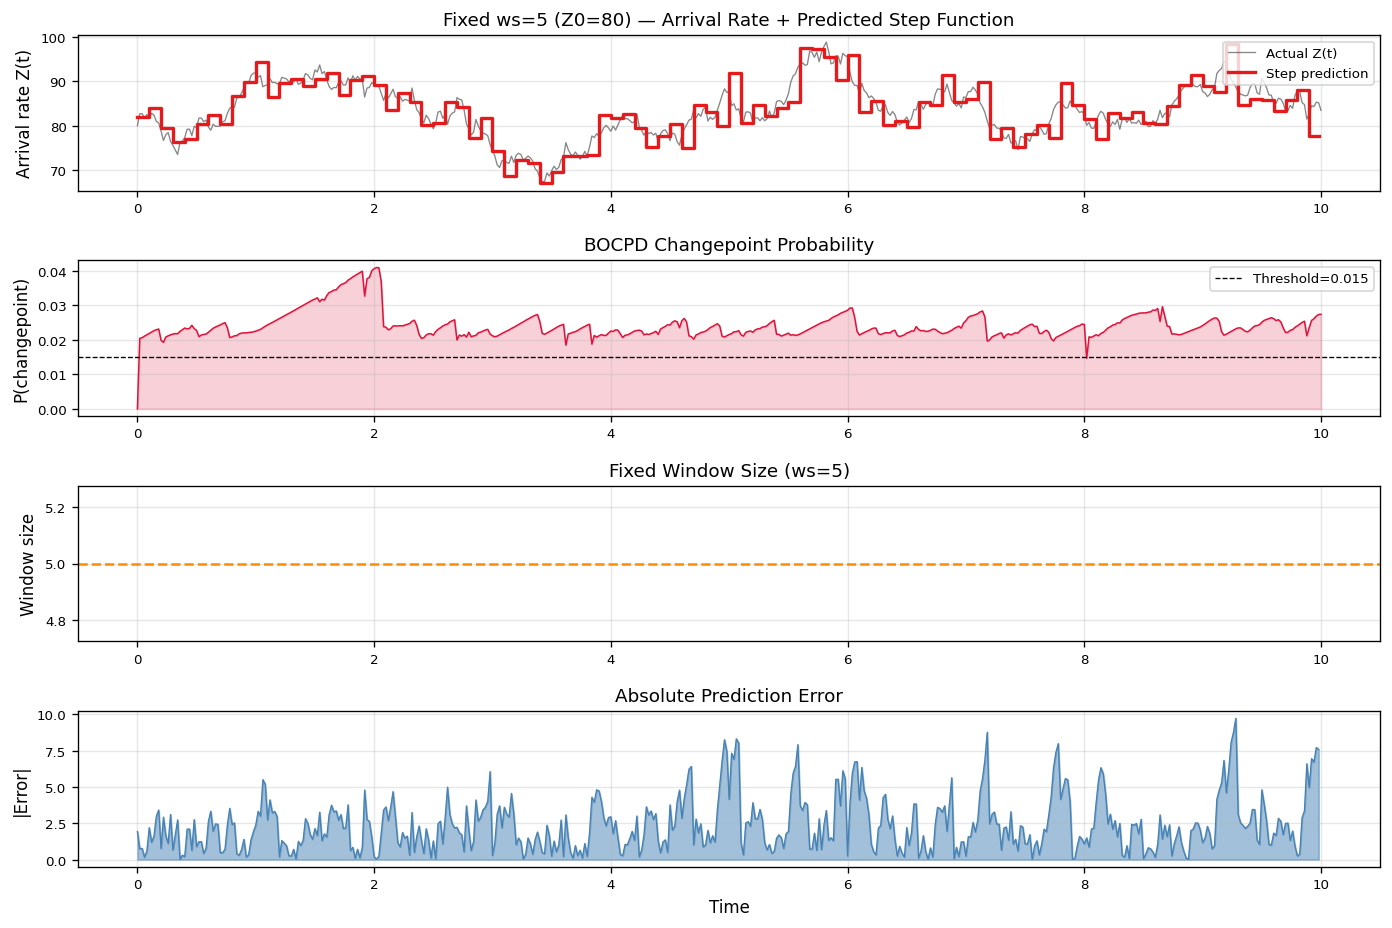

Saved → data_integrated/result_data/prediction_trace_fixed_ws10_Z080.png


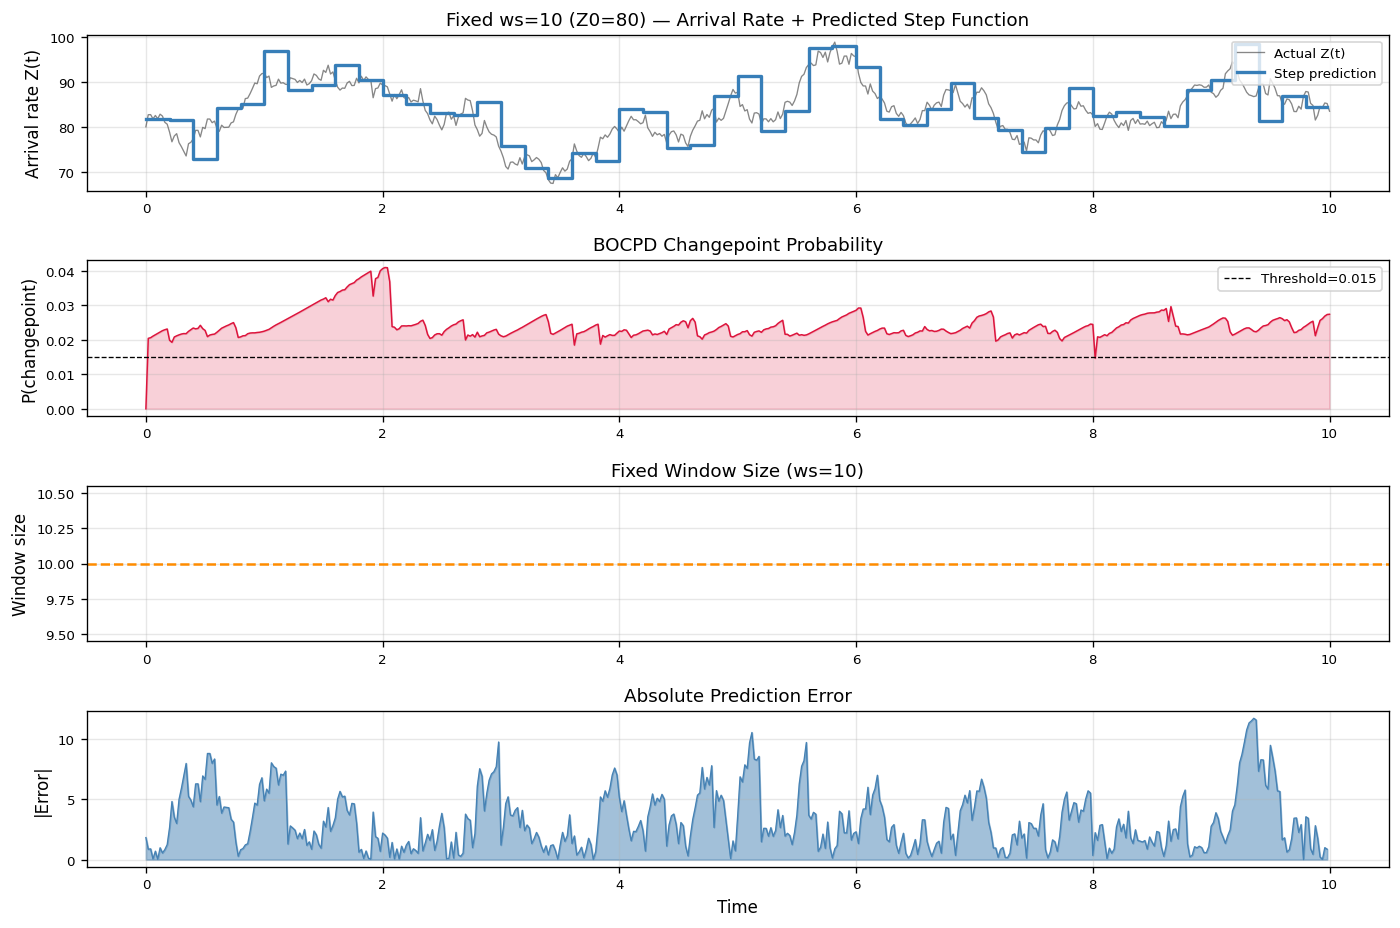

Saved → data_integrated/result_data/prediction_trace_adaptive_std_Z080.png


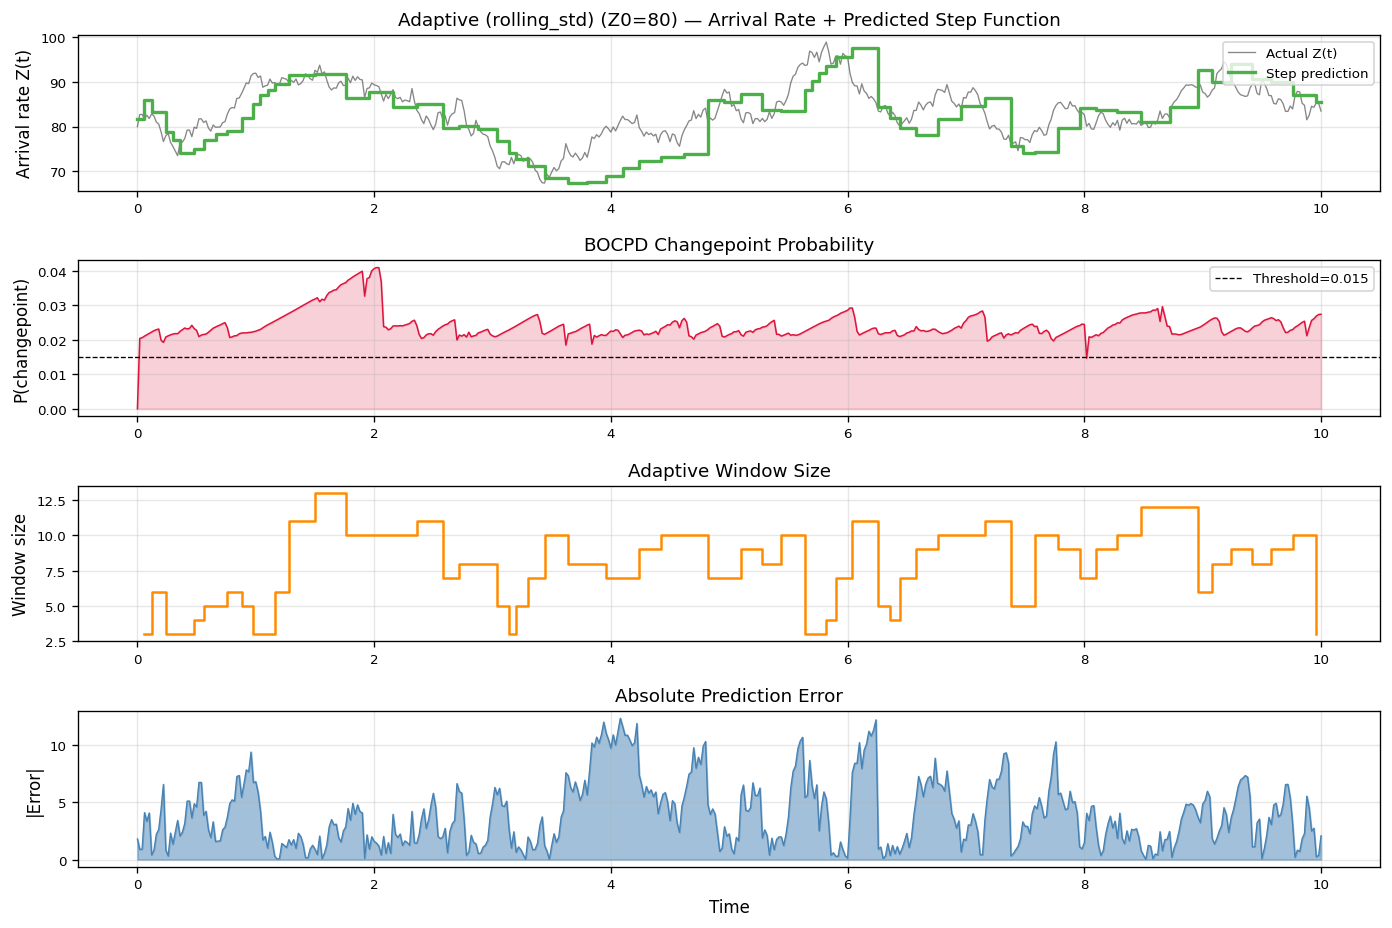

Saved → data_integrated/result_data/prediction_trace_adaptive_ewma_Z080.png


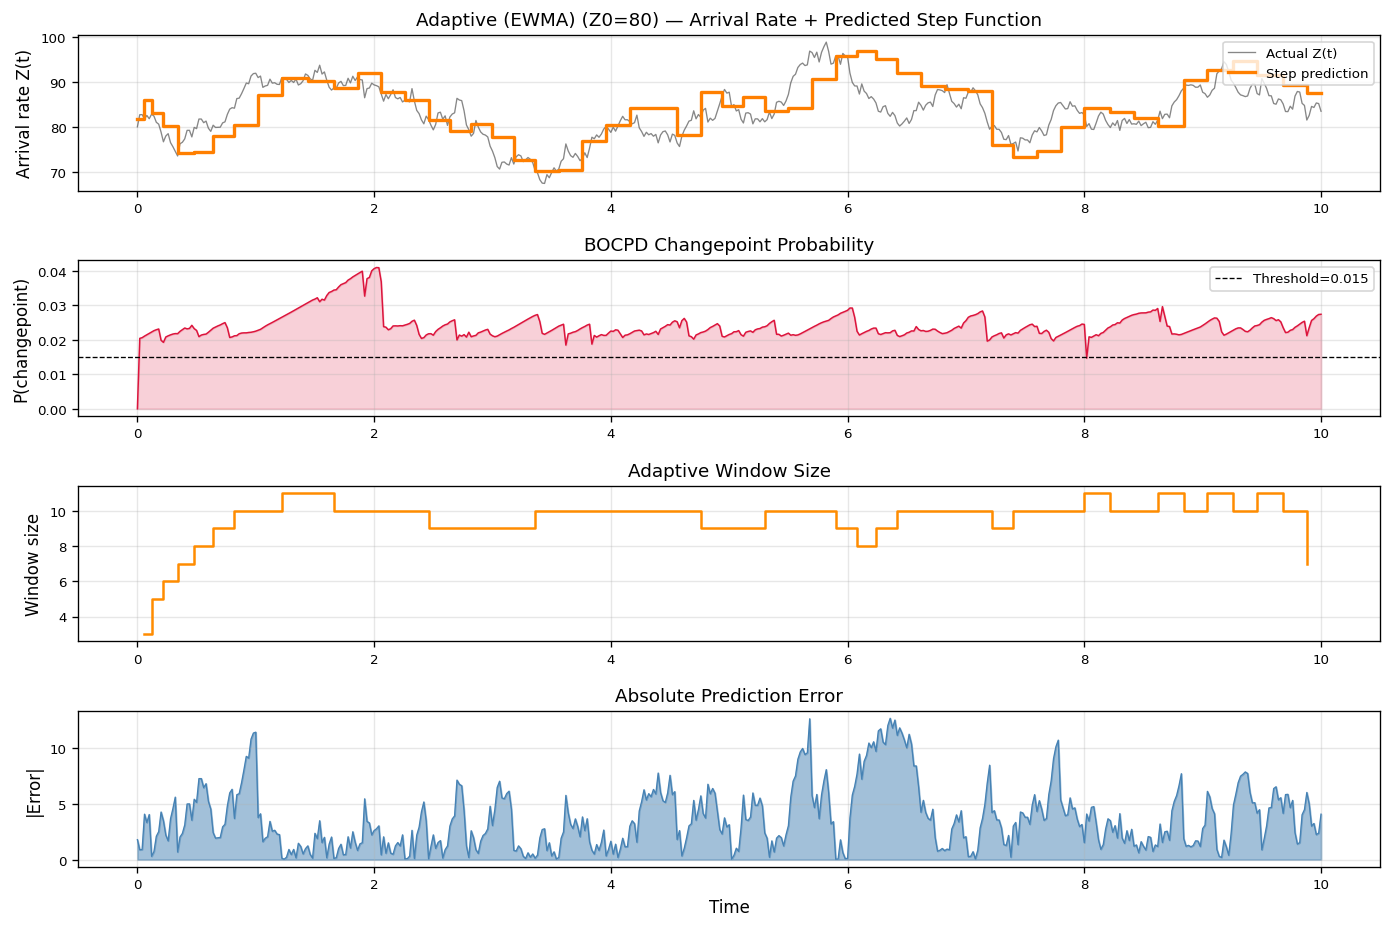

In [9]:
def plot_prediction_trace(strat_id, data, preds_dict, title='', dataset_tag=''):
    """4-panel: arrival rate + step fn / CP probs / window sizes / |error|."""
    if strat_id not in preds_dict:
        print(f'{strat_id} not in predictors')
        return
    _, _, pred = preds_dict[strat_id]
    r = pred.results

    actual    = pd.Series(r.get('actual_values', data['value'].values))
    step_raw  = r.get('predicted_step_function', r.get('stepwise_value', []))
    step      = pd.Series(step_raw).dropna().reset_index(drop=True)
    cp_probs  = pd.Series(r.get('changepoint_probs', [])).reset_index(drop=True)
    times_raw = r.get('prediction_times', data['time'].values)
    times     = pd.Series(times_raw.values if hasattr(times_raw, 'values') else times_raw)
    ws_log    = getattr(pred, 'window_sizes_used', [])

    fig = plt.figure(figsize=(14, 9))
    gs  = gridspec.GridSpec(4, 1, hspace=0.45)

    # Panel 1: Arrival rate + step function
    ax1 = fig.add_subplot(gs[0])
    t_ax = times[:len(actual)]
    ax1.plot(t_ax, actual, color='#555', lw=0.8, alpha=0.7, label='Actual Z(t)')
    if len(step) > 0:
        ax1.step(times[:len(step)], step,
                 color=STRAT_COLORS[strat_id], lw=2, where='post',
                 label='Step prediction')
    ax1.set_ylabel('Arrival rate Z(t)')
    ax1.set_title(f'{title} — Arrival Rate + Predicted Step Function')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # Panel 2: CP probabilities
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    if len(cp_probs) > 0:
        t_cp = times[:len(cp_probs)]
        ax2.plot(t_cp, cp_probs, color='crimson', lw=0.9)
        ax2.axhline(ALARM_THRESHOLD, color='k', ls='--', lw=0.8,
                    label=f'Threshold={ALARM_THRESHOLD}')
        ax2.fill_between(t_cp, 0, cp_probs, alpha=0.2, color='crimson')
    ax2.set_ylabel('P(changepoint)')
    ax2.set_title('BOCPD Changepoint Probability')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Panel 3: Window sizes
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    if ws_log:
        ws_times = [times.iloc[min(w[0], len(times)-1)] for w in ws_log]
        ws_vals  = [w[1] for w in ws_log]
        ax3.step(ws_times, ws_vals, color='darkorange', lw=1.5, where='post')
        ax3.set_title('Adaptive Window Size')
    else:
        fixed_ws = next((s['kwargs'].get('window_size', 5)
                         for s in STRATEGIES if s['id'] == strat_id), 5)
        ax3.axhline(fixed_ws, color='darkorange', lw=1.5, ls='--')
        ax3.set_title(f'Fixed Window Size (ws={fixed_ws})')
    ax3.set_ylabel('Window size')
    ax3.grid(True, alpha=0.3)

    # Panel 4: Absolute prediction error
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    if len(step) > 0:
        n   = min(len(actual), len(step))
        err = np.abs(actual.values[:n] - step.values[:n])
        ax4.fill_between(times[:n], 0, err, alpha=0.5, color='steelblue')
        ax4.plot(times[:n], err, color='steelblue', lw=0.8)
    ax4.set_xlabel('Time')
    ax4.set_ylabel('|Error|')
    ax4.set_title('Absolute Prediction Error')
    ax4.grid(True, alpha=0.3)

    tag  = f'_{dataset_tag}' if dataset_tag else ''
    fname = os.path.join(RESULT_DIR, f'prediction_trace_{strat_id}{tag}.png')
    plt.savefig(fname, bbox_inches='tight')
    print(f'Saved → {fname}')
    plt.show()


# 8 trace plots: 4 strategies × 2 datasets
for dataset_label, data, preds in [
    ('Z0=5',  data_z5,  predictors_z5),
    ('Z0=80', data_z80, predictors_z80),
]:
    tag = dataset_label.replace('=', '')
    for strat in STRATEGIES:
        plot_prediction_trace(
            strat['id'], data, preds,
            title=f"{strat['label']} ({dataset_label})",
            dataset_tag=tag,
        )

## 6 · PMF PDF-Style Overlay — best config, all t in one panel

Saved → data_integrated/result_data/pmf_pdf_style_serv10.png


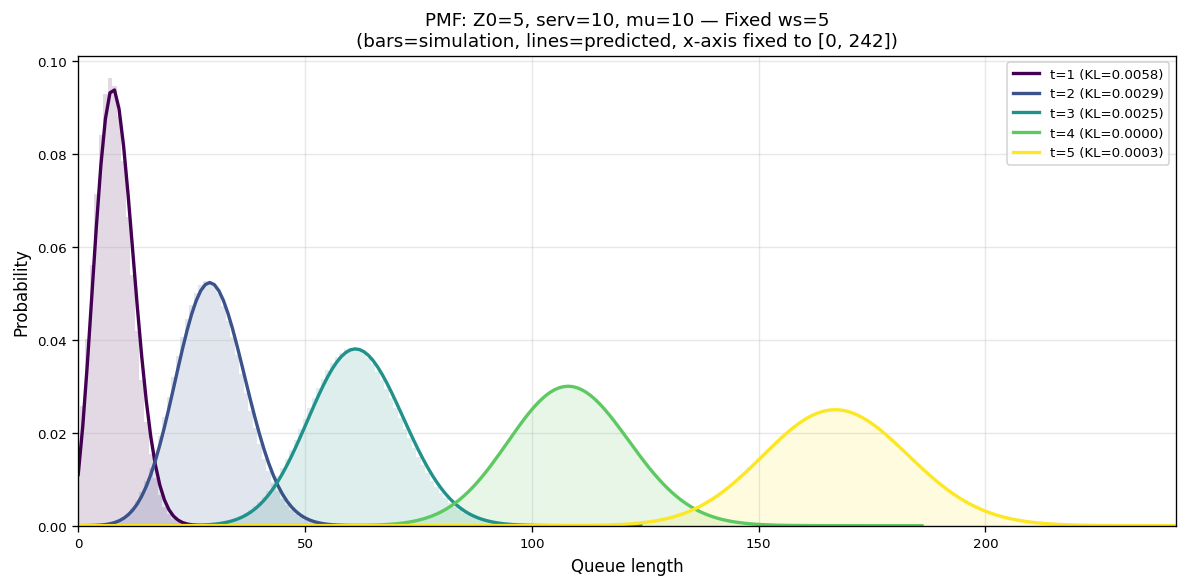

Saved → data_integrated/result_data/pmf_pdf_style_serv30.png


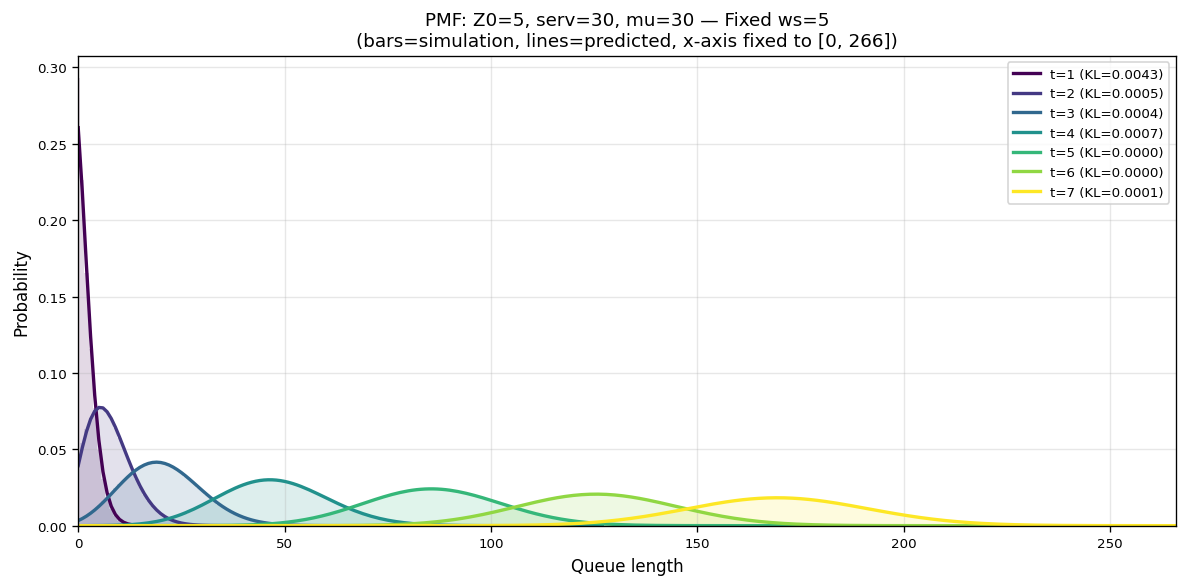

In [10]:
def plot_pdf_style_overlay(serv, T, t_vals_plot):
    """Single-panel PMF overlay for multiple t values — PDF style."""
    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(t_vals_plot) - 1, 1)) for i in range(len(t_vals_plot))]

    Z_piece, dt, _ = predictors['fixed_ws5']
    T_total = dt.sum()

    # Pre-compute to find shared x range
    pmfs_all = []
    for t in t_vals_plot:
        sim_pmf, mu_npz = load_npz(serv, T, t)
        if sim_pmf is None:
            pmfs_all.append(None)
            continue
        t_target = min(float(t), T_total * 0.99)
        try:
            pmf_pred = transient_distribution_piecewise(
                Z_piece, dt, mu=mu_npz, m=1, t=t_target, N=PMF_N)
        except Exception:
            pmf_pred = None
        pmfs_all.append((sim_pmf, mu_npz, pmf_pred))

    # Global x max
    x_max_list = []
    for entry in pmfs_all:
        if entry is None:
            continue
        sim_pmf, _, pmf_pred = entry
        for p in [sim_pmf, pmf_pred]:
            if p is not None:
                nz = np.where(p > 1e-5)[0]
                if len(nz):
                    x_max_list.append(nz[-1])
    global_xmax = (max(x_max_list) + 10) if x_max_list else 200

    fig, ax = plt.subplots(figsize=(10, 5))
    mu_use  = 10   # fallback

    for t, color, entry in zip(t_vals_plot, colors, pmfs_all):
        if entry is None:
            continue
        sim_pmf, mu_npz, pmf_pred = entry
        mu_use = mu_npz
        ax.bar(np.arange(len(sim_pmf)), sim_pmf,
               color=color, alpha=0.15, width=1.0)
        if pmf_pred is not None:
            n  = min(len(sim_pmf), len(pmf_pred))
            kl = calculate_kl_divergence(sim_pmf[:n], pmf_pred[:n])
            ax.plot(np.arange(n), pmf_pred[:n], color=color, lw=2,
                    label=f't={t} (KL={kl:.4f})')

    ax.set_xlim(0, global_xmax)
    ax.set_xlabel('Queue length')
    ax.set_ylabel('Probability')
    ax.set_title(
        f'PMF: Z0=5, serv={serv}, mu={mu_use:.0f} — Fixed ws=5\n'
        f'(bars=simulation, lines=predicted, x-axis fixed to [0, {global_xmax}])')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(RESULT_DIR, f'pmf_pdf_style_serv{serv}.png')
    plt.savefig(fname, bbox_inches='tight')
    print(f'Saved → {fname}')
    plt.show()


plot_pdf_style_overlay(serv=10, T=10, t_vals_plot=[1, 2, 3, 4, 5])
plot_pdf_style_overlay(serv=30, T=10, t_vals_plot=[1, 2, 3, 4, 5, 6, 7])

## 7 · KL vs t Line Plot (semi-log)

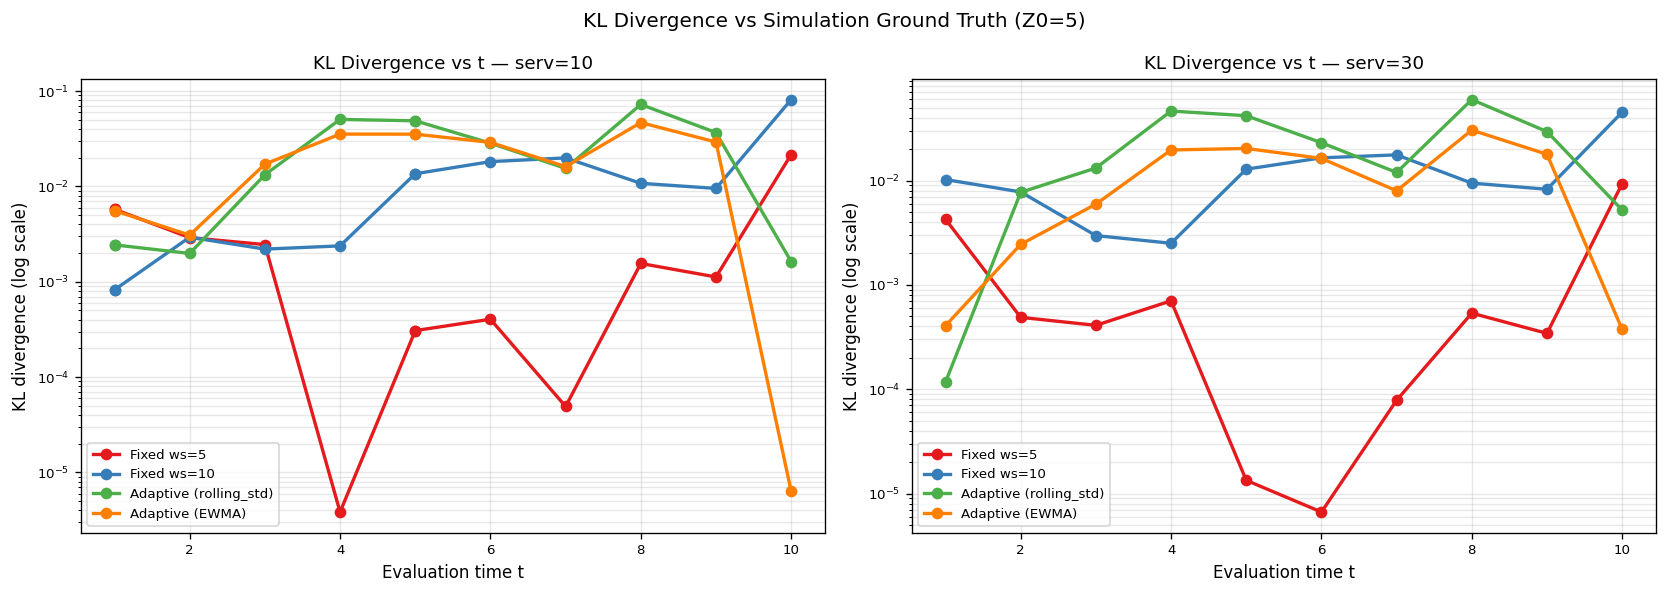

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, serv_val in zip(axes, [10, 30]):
    sub = df_kl[df_kl['service_rate'] == serv_val]
    for strat in STRATEGIES:
        sg = sub[sub['strategy_id'] == strat['id']].sort_values('t')
        if sg.empty:
            continue
        ax.semilogy(sg['t'], sg['kl'], 'o-',
                    color=STRAT_COLORS[strat['id']],
                    label=strat['label'], lw=2, ms=6)
    ax.set_xlabel('Evaluation time t')
    ax.set_ylabel('KL divergence (log scale)')
    ax.set_title(f'KL Divergence vs t — serv={serv_val}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('KL Divergence vs Simulation Ground Truth (Z0=5)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'kl_vs_t_lineplot.png'), bbox_inches='tight')
plt.show()